<a href="https://colab.research.google.com/github/baeunmangduck/LLM_SCRATCH/blob/main/LLM_%EA%B5%AC%ED%98%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tiktoken

#### 텍스트 데이터 다루기
- 토큰화는 LLM 모델이 수행하는 것이 아니라 tokenizer가 수행

In [ ]:
from importlib.metadata import version

print(version("torch"))
print(version("tiktoken"))

2.9.0+cpu
0.12.0


#### 단어 임베딩
- LLM은 고차원 공간 임베딩을 다룸

#### 텍스트 토큰화
- 텍스트를 개별 단어, 구둣점 문자 등을 기준으로 나눔
- 일단 Python re 라이브러리의 split 메서드를 기준으로 나눔

In [ ]:
import os
import urllib.request

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)


In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_txt = f.read()


print(f"총 문자 개수: {len(raw_txt)}")
print(raw_txt[:99])

총 문자 개수: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [ ]:
import re

text = "Hello, world. This, is a test."
result = re.split(r"(\s)", text)

print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [ ]:
result = re.split(r"([,.]|\s)", text)

print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [ ]:
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


In [ ]:
text = "Hello, world. Is this-- a test?"

result = re.split(r"([,.:;?_!\"()\']|--|\s)", text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [ ]:
preprocessed = re.split(r"([,.:;?_!\"()\']|--|\s)", raw_txt)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [ ]:
print(len(preprocessed))

4690


#### 토큰 -> 토큰 ID로 변환
- 텍스트를 토큰으로 나눈 후, 중복 제거
- 토큰에 id 번호 부여

In [ ]:
all_words = sorted(set(preprocessed))
vocab_size  = len(all_words)

print(vocab_size)

1130


##### 토큰 id 부여

In [ ]:
vocab = {token: integer for integer, token in enumerate(all_words)}

In [ ]:
for i, item in enumerate(vocab.items()):
  print(item)
  if i >= 10:
    break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)


In [ ]:
class SimpleTokenizerV1:

  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {integer: token for token, integer in vocab.items()}

  def encode(self, text):
    # 토큰화
    preprocessed = re.split(r"([,.:;?_!\"()\']|--|\s)", text)
    # 공백 제거
    preprocessed = [
        item.strip() for item in preprocessed if item.strip()
    ]
    # 토큰 id 생성
    ids = [self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self, ids):
    # 역토큰화
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

In [ ]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know,"
           Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [ ]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

#### 특수 문맥 토큰 추가
- 알지 못하는 단어와 텍스트의 시작과 끝을 알려주는 특수 토큰을 추가하면 도움이 됨
- GPT-2 의 경우 텍스트의 끝(<|endoftext|>)을 알려주는 특수 토큰만 사용
- 이외의 토크나이저
  - BOS(Beginning Of Sequence): 텍스트의 시작
  - EOS(End of Sequence): 텍스트의 끝
  - PAD(Padding): 길이가 다른 텍스트의 길이를 동일하게 만들기 위해 사용
  - UNK: 어휘사전에 없는 단어를 나타냄

##### 현재의 토크나이저는 해당 토큰이 어휘사전에 없으면 처리 불가

In [ ]:
# tokenizer = SimpleTokenizerV1(vocab)
# text = "Hello, do you like tea. Is this-- a test?"
# tokenizer.encode(text)

##### Unknown 토큰과 End of Text 토큰 추가하기

In [ ]:
all_tokens = sorted(set(list(preprocessed)))
len(all_tokens)

1130

In [ ]:
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer, token in enumerate(all_tokens)}

In [ ]:
len(all_tokens)

1132

In [ ]:
for i, item in enumerate(list(vocab.items())[-5:]):
  print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


##### Unknown 토큰을 사용하기 위한 토크나이저 수정 진행

In [ ]:
class SimpleTokenizerV2:

  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {integer: token for token, integer in vocab.items()}

  def encode(self, text):
    # 토큰화
    preprocessed = re.split(r"([,.:;?_!\"()\']|--|\s)", text)
    # 공백 제거
    preprocessed = [
        item.strip() for item in preprocessed if item.strip()
    ]
    # 토큰 id 생성 (어휘사전(str_to_int)에 단어가 없을 경우 unknown 토큰 적용)
    preprocessed = [
       item if item in self.str_to_int else "<|unk|>" for item in preprocessed
           ]
    ids = [self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self, ids):
    # 역토큰화
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

In [ ]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace"

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace


In [ ]:
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131]

In [ ]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>'

#### 바이트 페어 인코딩
- GPT 계열에서 사용하는 토큰화 방법
- BPE 어휘사전 구축 방법
  - 개별 문자를 어휘사전에 등록
  - 그 다음 자주 등장하는 문자 조합을 부분단어로 등록



In [ ]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
    "of someunknownPlace."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [ ]:
tokenizer.special_tokens_set

{'<|endoftext|>'}

In [ ]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


#### 슬라이딩 윈도우
- LLM은 훈련 시, 타킷 이후의 단어를 참조하지 못하도록 함.
- 슬라이딩 윈도우로 지정된 값씩 다음 토큰을 입력으로 함.


In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [ ]:
enc_sample = enc_text[50:]

In [ ]:
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1: context_size + 1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [ ]:
for i in range(1, context_size + 1):
  context = enc_sample[:i]
  desired = enc_sample[i]

  print(context, "----> ", desired)

[290] ---->  4920
[290, 4920] ---->  2241
[290, 4920, 2241] ---->  287
[290, 4920, 2241, 287] ---->  257


In [ ]:
for i in range(1, context_size + 1):
  context = enc_sample[:i]
  desired = enc_sample[i]

  print(tokenizer.decode(context), "----> ", tokenizer.decode([desired]))

 and ---->   established
 and established ---->   himself
 and established himself ---->   in
 and established himself in ---->   a


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):

  def __init__(self, txt, tokenizer, max_length, stride) -> None:
    self.input_ids = []
    self.target_ids = []

    # 전체 텍스트 토큰화
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
    assert len(token_ids) > max_length # 토큰 id의 길이 max_length 보다는 커야 함.

    # 슬라이딩 윈도우를 사용하여 나눔 (stride가 결정)
    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i: i + max_length]
      target_chunk = token_ids[i + 1: i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))


  def __len__(self) -> int:
    return len(self.input_ids)

  def __getitem__(self, idx) -> list:
    return self.input_ids[idx], self.target_ids[idx]





In [ ]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0
                         ):
  tokenizer = tiktoken.get_encoding("gpt2")

  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  dataloader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=True,
      drop_last=drop_last,
      num_workers=num_workers
  )
  return dataloader

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[  198,     1, 12295,   892]]), tensor([[    1, 12295,   892,   286]])]


In [ ]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[3137,  257, 3465, 2077]]), tensor([[ 257, 3465, 2077,  351]])]


#### 토큰 임베딩 만들기
- 토큰 id를 변환하기 까지의 과정은 tokenizer의 역할
- 토큰 임베딩 과정부터는 LLM에서 관여
- 처음에는 랜덤값으로 초기화됨
- 이후, LLM 모델은 주변의 토큰의 영향을 받아 임베딩이 의미있는 값으로 학습됨


In [ ]:
input_ids = torch.tensor([2, 3, 5, 1])


##### 먼저 가중치 행렬 생성
- 토큰 id에 따른 인덱스를 통해 토큰 임베딩을 가져옴
- lookup 연산이라고 볼 수 있음

In [ ]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)


In [ ]:
print(embedding_layer)
print(embedding_layer.weight)

Embedding(6, 3)
Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [ ]:
# 토큰 id: 2의 embedding 값
embedding_layer(torch.tensor([2]))

tensor([[ 1.2753, -0.2010, -0.1606]], grad_fn=<EmbeddingBackward0>)

In [ ]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


#### 단어 위치 인코딩
- 기존 임베딩 층은 위치에 상관 없이 토큰 ID에 따라 동일한 벡터 표현
- 그러나 토큰의 위치에 따라 의미 및 역할이 달라질 수 있음
- 따라서 위치에 대한 고려를 해야 함.
- 이를 위해 위치 인코딩을 추가

In [ ]:
vocab_size = 50257
output_dim = 256

In [ ]:
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [ ]:
max_length = 4
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [ ]:
print("토큰ID: ", inputs)
print("입력 크기: ", inputs.shape)


토큰ID:  tensor([[24818,   417,    12, 12239],
        [  314,  3114,   379,   262],
        [ 2156,   286,  4116,    13],
        [  866,   262,  2119,    11],
        [ 3363,    11,   340,   373],
        [  198,     1,    40,  2900],
        [  465, 14475,    13,   198],
        [ 3081,   286,  2045,  1190]])
입력 크기:  torch.Size([8, 4])


In [ ]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)
print(token_embeddings)
# 배치 개수, 토큰 개수, 임베딩

torch.Size([8, 4, 256])
tensor([[[-0.0673, -0.3863, -0.5027,  ..., -1.0610,  0.5170,  0.4422],
         [-1.0366,  0.8779,  0.4560,  ..., -0.6743,  0.9195, -1.5858],
         [-0.4357,  0.5339,  0.2413,  ...,  0.5189, -1.9390,  0.8580],
         [ 1.1013, -0.2652,  0.7247,  ...,  0.3632, -0.5016,  0.1404]],

        [[ 0.5786, -1.8926, -1.7647,  ..., -0.1368,  0.3491,  2.1122],
         [-1.1059, -0.3257,  0.1568,  ...,  0.1386,  1.0505, -0.1206],
         [-1.3986,  0.7459, -0.0840,  ..., -1.9663,  0.8480, -0.8870],
         [-0.3962,  0.5593,  3.4120,  ...,  0.6146, -0.3981,  0.7999]],

        [[ 0.4188, -0.2066, -1.1127,  ..., -0.1625,  1.9322,  0.6564],
         [-0.5594,  1.2612, -0.9617,  ..., -0.8864, -0.0426, -2.1107],
         [ 0.3512,  0.0883, -0.3792,  ..., -0.0899, -0.0107,  0.8041],
         [-1.1577, -1.9382,  0.9027,  ..., -0.0718, -0.8468, -1.0623]],

        ...,

        [[-0.1437, -0.9782,  1.5918,  ...,  0.3068, -1.1135, -0.7202],
         [ 1.2277, -0.4297, -2.21

In [ ]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

print(pos_embedding_layer.weight)
print(pos_embedding_layer.weight.shape)

Parameter containing:
tensor([[-0.6303, -0.4848, -0.1366,  ...,  1.0345, -0.5012,  1.1045],
        [ 0.2062,  0.6078,  0.7187,  ..., -0.4628, -0.2319,  1.1980],
        [ 0.5806, -1.3846,  0.3266,  ...,  0.8579,  0.5059,  1.0243],
        [ 1.4323,  0.2217,  0.8599,  ...,  0.4827,  0.8459,  1.3038]],
       requires_grad=True)
torch.Size([4, 256])


In [ ]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)
print(pos_embeddings)

torch.Size([4, 256])
tensor([[-0.6303, -0.4848, -0.1366,  ...,  1.0345, -0.5012,  1.1045],
        [ 0.2062,  0.6078,  0.7187,  ..., -0.4628, -0.2319,  1.1980],
        [ 0.5806, -1.3846,  0.3266,  ...,  0.8579,  0.5059,  1.0243],
        [ 1.4323,  0.2217,  0.8599,  ...,  0.4827,  0.8459,  1.3038]],
       grad_fn=<EmbeddingBackward0>)


In [ ]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)
print(input_embeddings)

torch.Size([8, 4, 256])
tensor([[[-6.9761e-01, -8.7118e-01, -6.3931e-01,  ..., -2.6479e-02,
           1.5865e-02,  1.5467e+00],
         [-8.3036e-01,  1.4857e+00,  1.1747e+00,  ..., -1.1372e+00,
           6.8757e-01, -3.8783e-01],
         [ 1.4487e-01, -8.5069e-01,  5.6792e-01,  ...,  1.3768e+00,
          -1.4331e+00,  1.8823e+00],
         [ 2.5337e+00, -4.3586e-02,  1.5846e+00,  ...,  8.4595e-01,
           3.4431e-01,  1.4442e+00]],

        [[-5.1686e-02, -2.3774e+00, -1.9013e+00,  ...,  8.9769e-01,
          -1.5203e-01,  3.2167e+00],
         [-8.9968e-01,  2.8205e-01,  8.7554e-01,  ..., -3.2424e-01,
           8.1862e-01,  1.0773e+00],
         [-8.1801e-01, -6.3869e-01,  2.4258e-01,  ..., -1.1084e+00,
           1.3538e+00,  1.3730e-01],
         [ 1.0362e+00,  7.8096e-01,  4.2719e+00,  ...,  1.0973e+00,
           4.4780e-01,  2.1037e+00]],

        [[-2.1142e-01, -6.9142e-01, -1.2493e+00,  ...,  8.7200e-01,
           1.4310e+00,  1.7609e+00],
         [-3.5321e-01,  1.8

#### 연습문제 2.1
- BPE를 사용하여 "Akwirw ier" 단어 인코딩하기

In [ ]:
import tiktoken

test_tokenizer = tiktoken.get_encoding("gpt2")
test_text = "Akwirw ier"
for i in test_tokenizer.encode(test_text):
  print(f"{i} -> {test_tokenizer.decode([i])}")

33901 -> Ak
86 -> w
343 -> ir
86 -> w
220 ->  
959 -> ier


#### 연습문제 2.2
- dataloader를 사용하여 데이터를 준비
- max_length = 2, stride = 2
- max_lenght = 8, stride = 2

In [ ]:
import os
import urllib.request

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)


In [ ]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader


In [ ]:
class GPTDatasetV1(Dataset):

  def __init__(self, txt, tokenizer, max_length, stride) -> None:
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i: i + max_length]
      target_chunk = token_ids[i + 1: i + max_length + 1 ]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]


def create_dataloader(txt, batch_size=4, max_length=256, stride=128):

  tokenizer = tiktoken.get_encoding("gpt2")

  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  dataloader = DataLoader(dataset, batch_size=batch_size)

  return dataloader



with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

tokenizer = tiktoken.get_encoding("gpt2")
encoded_text = tokenizer.encode(raw_text)

vocab_size=50257
output_dim = 256
max_len = 4
context_length = max_len

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)


In [ ]:
dataloader = create_dataloader(raw_text, batch_size=4, max_length=2, stride=2)

for batch in dataloader:
  x, y = batch
  break

x, y

(tensor([[  40,  367],
         [2885, 1464],
         [1807, 3619],
         [ 402,  271]]),
 tensor([[  367,  2885],
         [ 1464,  1807],
         [ 3619,   402],
         [  271, 10899]]))

In [ ]:
dataloader = create_dataloader(raw_text, batch_size=4, max_length=8, stride=2)

for batch in dataloader:
  x, y = batch
  break

x, y

(tensor([[   40,   367,  2885,  1464,  1807,  3619,   402,   271],
         [ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138],
         [ 1807,  3619,   402,   271, 10899,  2138,   257,  7026],
         [  402,   271, 10899,  2138,   257,  7026, 15632,   438]]),
 tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899],
         [ 1464,  1807,  3619,   402,   271, 10899,  2138,   257],
         [ 3619,   402,   271, 10899,  2138,   257,  7026, 15632],
         [  271, 10899,  2138,   257,  7026, 15632,   438,  2016]]))

#### 어텐션 메커니즘 구현
- 등장 배경: 긴 시퀀스 모델링의 문제점
  - 인코더-디코더 기반의 RNN의 경우 인코더의 최종(하나의) 은닉상태에 압축되어 디코더가 번역
  - 긴 시퀀스일 경우 앞의 문맥을 파악하기 어렵다는 문제가 발생

- 바흐다나우 어텐션
  - 위의 문제를 해결하기 위해 제안된 최초의 어텐션 구조
  - 출력 토큰을 생성 시에 모델이 모든 입력 토큰을 참조
  - 다만, 이전의 입력 토큰 정보를 모두 저장하고 있어야 함.
  - 위의 문제로 인해 저장공간 및 메모리, 입력 텍스트 상의 문제가 생김

- 셀프 어텐션 메커니즘
  - 인코더의 은닉상태를 참조하지 않고, 자기 자신의 토큰만을 참조하는 방식

#### 어텐션 메커니즘과 데이터 종속성
- 신경망의 텍스트 생성 디코더가 모든 입력 토큰을 선택적으로 참조
- 셀프 어텐션은 특히 시퀀스에 있는 각 위치가 **동일 시퀀스**에 있는 모든 다른 위치와 상호작용하여 관련성을 결정 (디코더층만 사용)

#### 훈련 가능한 가중치가 없는 간단한 셀프 어텐션 메커니즘
- 어텐션 점수: Query와 Key를 점곱한 결과
- 어텐션 가중치: 어텐션 점수를 정규화한 값, 다른 가중치와 달리 학습 가능한 파라미터가 아님


In [ ]:
import torch

inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89], # Your
        [0.55, 0.87, 0.66], # Journey
        [0.57, 0.85, 0.64], # starts
        [0.22, 0.58, 0.33], # with
        [0.77, 0.25, 0.10], # one
        [0.05, 0.80, 0.55], # step
    ]
)

In [ ]:
## 두번째 토큰을 쿼리로 가정
query = inputs[1]
print(query)

## 어텐션 점수 계산
attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(x_i, query)

print(attn_scores_2)

tensor([0.5500, 0.8700, 0.6600])
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [ ]:
### 어텐션 점수를 어텐션 가중치로 변환시키기 위해 정규화
attn_weights_2 = attn_scores_2 / torch.sum(attn_scores_2)

print(attn_weights_2)
print(torch.sum(attn_weights_2))

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
tensor(1.0000)


In [ ]:
def softmax_naive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)
print(attn_weights_2_naive )

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


In [ ]:
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
  context_vec_2 += attn_weights_2[i] * x_i

print(context_vec_2)


tensor([0.4355, 0.6451, 0.5680])


In [ ]:
## 모든 입력 토큰에 대해 어텐션 가중치 계산

attn_scores = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [ ]:
attn_scores = inputs @ inputs.T

In [ ]:
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [ ]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [ ]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


#### 훈련 가능한 가중치를 가진 셀프 어텐션 구현
- 이전에는 단어 임베딩을 그대로 사용하여 Query, Key, Value에 가중치 값을 적용하지 않음
- 현재는 Query, Key, Value 값에 가중치와 토큰 값을 곱함
- 셀프 어텐션 메커니즘을 스케일드 점곰 어텐션이라고도 부름
- 이전의 메커니즘과 가장 큰 차이는 업데이트되는 가중치 행렬이 있다는 것

In [ ]:
# inputs (6, 3)
# q, k, v (3, 2)
# w (6, 2)

x_2 = inputs[1] # (1, 3)
d_in = inputs.shape[1] # 3
d_out = 2


In [ ]:
x_2

tensor([0.5500, 0.8700, 0.6600])

In [ ]:
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False) # (3, 2)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False) # (3, 2)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False) # (3, 2)

In [ ]:
query_2 = x_2 @ W_query # (1, 2)
key_2 = x_2 @ W_key # (1, 2)
value_2 = x_2 @ W_value # (1, 2)

In [ ]:
print(query_2)

tensor([0.4306, 1.4551])


In [ ]:
keys = inputs @ W_key # (6 , 3) (3, 2) -> (6, 2)
values = inputs @ W_value
print(keys.shape)
print(values.shape)

torch.Size([6, 2])
torch.Size([6, 2])


In [ ]:
keys_2 = keys[1]
attn_score_22 = query_2 @ keys_2.T # (1,2) / (2) -> (1,)
attn_score_22

/tmp/ipython-input-974544967.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4416.)
  attn_score_22 = query_2 @ keys_2.T # (1,2) / (2) -> (1,)


tensor(1.8524)

In [ ]:
attn_scores_2 = query_2 @ keys.T # (1, 2) / (6, 2) -> (1, 6)
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [ ]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k ** 0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [ ]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


In [ ]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

  def __init__(self, d_in, d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in, d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value

    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )

    context_vec = attn_weights @ values

    return context_vec



In [ ]:
  torch.manual_seed(123)
  sa_v1 = SelfAttention_v1(d_in, d_out)
  print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [ ]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):

  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    keys = self.W_key(x)     # (Batch, Seq_Len, d_out)
    queries = self.W_query(x) # (Batch, Seq_Len, d_out)
    values = self.W_value(x)   # (Batch, Seq_Len, d_out)

    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )

    context_vec = attn_weights @ values

    return context_vec



In [ ]:
  torch.manual_seed(789)
  sa_v2 = SelfAttention_v2(d_in, d_out)
  print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


#### 코잘 어텐션 적용
- 시퀀스의 특정 위치에서 모델의 예측이 미래 위치가 아니라 이전 위치의 출력에만 의존
- 다음 단어 예측은 철저히 이전 단어에만 의존
- 미래 토큰에 대해 마스킹 적용

In [ ]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


##### tril 함수 사용 시, 주대각선과 아래의 원소만 1, 나머지는 0인 마스크 사용 가능

In [ ]:
context_length = attn_scores.shape[0]
print(context_length)
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

6
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [ ]:
masked_simple = attn_weights * mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [ ]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


#### 좀 더 효율적으로 위의 과정을 하기 위해서는 주대각선 위의 어텐션 가중치를 0으로 만들고 그 결과를 재정규화하는 대신에 소프트맥스 함수에 들어가기 전에 어텐션 점수를 음의 무한대로 마스킹

In [ ]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [ ]:
attn_weights = torch.softmax(masked / keys.shape[-1] ** 0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


#### 드롭아웃
- 과대적합을 방지하기 위한 방법
- 일반적으로는 어텐션 가중치를 계산한 후, 적용
- 만약 훈련 시에 드롭아웃 비율을 50%로 설정할 경우, 추론 시에는 2배 만큼 크기를 증가시켜야 함.

In [ ]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [ ]:
class CasualAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)     # (Batch, Seq_Len, d_out) -> (2, 6, 1) X (2, 1 6) -> (2, 6, 6) (2, 6, 1)
    queries = self.W_query(x) # (Batch, Seq_Len, d_out)
    values = self.W_value(x)   # (Batch, Seq_Len, d_out)

    attn_scores = queries @ keys.transpose(1, 2)
    attn_scores.masked_fill_(
        self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    attn_weights = self.dropout(attn_weights)
    context_vec = attn_weights @ values

    return context_vec


In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CasualAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)

print(context_vecs)
print(context_vecs.shape)



tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
torch.Size([2, 6, 2])


#### 싱글 헤드 어텐션 → 멀티헤드 어텐션

#### 1) Casual Attention 을 병렬로 여러번 실행

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    self.heads = nn.ModuleList(
        [CasualAttention(d_in, d_out, context_length, dropout, qkv_bias)
        for _ in range(num_heads)]
    )


  def forward(self, x):
    return torch.cat([head(x) for head in self.heads], dim=-1)



In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1] # 6
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)

context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)


tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
torch.Size([2, 6, 4])


#### 가중치 분할로 멀티 헤드 어텐션 구현
- 하나의 큰 W_query, W_key, W_value 가중치 행렬을 만든 다음 헤드 개수만큼 분할

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), \
    "d_out은 num_heads로 나누어져야 함."

    self.d_out = d_out # 2
    self.num_heads = num_heads # 2
    self.head_dim = d_out // num_heads # 1

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias) # (3, 2)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias) #
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape # 2, 6, 3
    keys = self.W_key(x)     # (batch, num_tokens, d_out)  -> (2, 6, 2)
    queries = self.W_query(x) # (batch, num_tokens, d_out)
    values = self.W_value(x)   # (batch, num_tokens, d_out)

    # num_heads 추가하며 사실상 행렬을 분할
    # (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim) -> (2, 6, 2, 1)
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    # 전치: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim) -> (2, 2, 6, 1) X (2, 2, 1, 6)
    keys = keys.transpose(1, 2)
    values = values.transpose(1, 2)
    queries = queries.transpose(1, 2)

    # 스케일드 점곱
    attn_scores = queries @ keys.transpose(2, 3) # (2, 2, 6, 6)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_scores.masked_fill_(
        mask_bool, -torch.inf)
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    attn_weights = self.dropout(attn_weights)
    # (b, num_tokens, num_heads, head_dim)
    context_vec = (attn_weights @ values).transpose(1, 2) # (2, 6, 2, 1)

    # 헤드 결합
    context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out) # (2, 6, 2)
    context_vec = self.out_proj(context_vec)

    return context_vec


In [ ]:
torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape # (2, 6, 3)
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)


tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
torch.Size([2, 6, 2])


#### 연습문제
- 멀티헤드 어텐션의 출력 차원이 2이어야 함

In [ ]:
# (2, 6, 3) 인 batch에서 하나의 CasualAttention이 (2, 6, 1) 로 나오고 이 것을 num_heads가 2개이기 때문에 병렬로 이어붙이지면 (2, 6, 2)가 도출됨
torch.manual_seed(123)
context_length = batch.shape[1] # 6
d_in, d_out = 3, 1
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)

context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)


tensor([[[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]],

        [[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]]], grad_fn=<CatBackward0>)
torch.Size([2, 6, 2])


In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1] # 6
d_in, d_out = 3, 2
mha = MultiHeadAttention(d_in, d_out, context_length, dropout=0.0, num_heads=2)
context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
torch.Size([2, 6, 2])


#### LLM 구조 구현
- LLM의 규모가 크다는 의미는 코드 수가 아닌 파라미터의 개수
- 트랜스포머 블록의 구성 요소
  - 층 정규화
  - GELU 활성화 함수
  - 피드 포워드 네트워크
  - 숏컷 연결

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # 어휘사전 크기
    "context_length": 1024, # 입력 토큰의 최대 개수
    "emb_dim": 768, # 임베딩 크기
    "n_heads": 12, # 멀티 헤드 개수 -> 즉, 각 헤드에서는 64 차원
    "n_layers": 12, # 층 개수
    "drop_rate": 0.1, # 드롭아웃 비율
    "qkv_bias": False # 쿼리, 키, 값 생성 시 편향 포함 여부
}

In [ ]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):

  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
        *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )

    self.final_norm = DummyLayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    in_idx = in_idx.long()
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

class DummyTransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    ## 더미 클래스

  def forward(self, x):
    return x


class DummyLayerNorm(nn.Module):
  def __init__(self, normalized_shape, eps=1e-5):
    super().__init__()

  def forward(self, x):
    return x


In [ ]:
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")

batch = list()

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.Tensor(tokenizer.encode(txt1)))
batch.append(torch.Tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109., 3626., 6100.,  345.],
        [6109., 1110., 6622.,  257.]])


In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(cfg=GPT_CONFIG_124M)

logits = model(batch)
print(logits.shape)
print(logits)

torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


#### 층정규화
- 보통 정규화는 표준화로 평균 0 이고 표준편차가 1이 되도록 값을 조절해주는 행위
- 데이터 사이에서의 scale이 다를 경우 학습 속도 및 성능이 저하될 수 있기 때문에 정규화
- 정규화의 종류
  - 배치정규화:
    - 세로 방향 연산
    - 특성별 정규화
    - 타 데이터에 의해 영향을 받을 수 있음

  - 층정규화:
    - 가로 방향 연산
    - 각 데이터(토큰)별 정규화
    - 즉 하나의 데이터의 모든 특성 정규
    - 타 데이터에 영향을 받지 않음
- 층정규화 적용 위치: 트랜스포머 블록 멀티 어텐션 모듈 전후, 최종 출력 전에 적용


In [ ]:
torch.manual_seed(123)

batch_example = torch.randn(2, 5)

layer = nn.Sequential(
    nn.Linear(5, 6),
    nn.ReLU()
)
# ReLU 함수에 의해 0 이하의 값들은 모두 0으로 출력됨
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [ ]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print(f"평균: {mean}")
print(f"분산: {var}")

평균: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
분산: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


#### 표준화

In [ ]:
out_norm = (out - mean) / torch.sqrt(var)
print(f"정규화된 층 출력: {out_norm}")

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)


print(f"층정규화된 평균: {mean}")
print(f"층정규화된 분산: {var}")

정규화된 층 출력: tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
층정규화된 평균: tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
층정규화된 분산: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [ ]:
torch.set_printoptions(sci_mode=False)

### 🧠 Layer Normalization: scale, shift, eps 핵심 요약

---

#### **1. scale ($\gamma$) & shift ($\beta$) : 표현력 복원**
* **표준화의 한계 보완**: 모든 입력을 평균 0, 분산 1로 고정할 경우 모델의 **표현 다양성(Representational Power) 감소** 방지
* **최적의 분포 재설정**: 신경망이 학습에 가장 적합하다고 판단하는 위치로 **데이터 분포를 다시 변형**
    * **scale**: 분포의 폭(분산)을 조절하여 정보의 강도 조정 (곱셈 연산)
    * **shift**: 분포의 중심(평균)을 이동시켜 활성화 함수의 최적 영역 활용 (덧셈 연산)
* **학습 데이터 맞춤화**: 고정된 상수가 아닌 `nn.Parameter`로서 **역전파를 통해 최적값으로 자동 업데이트**



---

#### **2. self.eps (Epsilon) : 수치적 안전장치**
* **Zero Division 방지**: 모든 특성값이 동일하여 **분산이 0이 되는 상황**에서 연산 오류(NaN) 차단
* **계산 안정성 확보**: 분산이 매우 작을 때 결과값이 무한대로 발산하는 것을 막는 **최소한의 완충 지대**
* **정밀도 유지**: 루트 연산 및 나눗셈 시 발생할 수 있는 컴퓨터의 **수치적 불안정성 보정**

---

#### **💡 요약 (구 형태)**
* **정규화**: 데이터를 '무색무취'하게 표준화하여 학습 기초 형성
* **아핀 변환(Affine Transform)**: `scale`과 `shift`를 통해 모델이 필요로 하는 특성을 다시 입히는 과정
* **상호보완 구조**: `eps`로 **연산 안정성** 확보, `scale`/`shift`로 **모델 유연성** 확보

In [ ]:
class LayerNorm(nn.Module):

  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)

    return self.scale * norm_x + self.shift



In [ ]:
ln = LayerNorm(emb_dim=5)
out_ln =ln(batch_example)

In [ ]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)
print(mean, var)

tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>) tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### GeLU 활성화 함수
- ReLU 함수의 경우 0 이하의 값을 0으로 처리하기 때문에 미분에 어려움이 있음
- 이러한 문제를 해결하기 위해 GELU를 사용
- 피드 포워드 네트워크에 포함됨
- 피드 포워드 네트워크는 임베딩 층의 너비를 넓히고 줄이는 역할

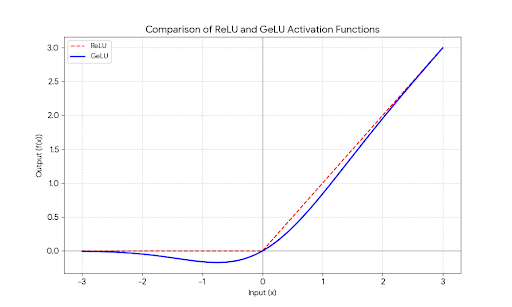

In [ ]:
class GELU(nn.Module):

  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * ( 1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
         (x + 0.44715 * torch.pow(x, 3))
    ))

#### ReLU VS GeLU
- ReLU는 양수는 그대로 출력하고, 음수는 모두 0을 출력하는 구간별 선형 함수
- GELU는 부드러운 비선형 함수

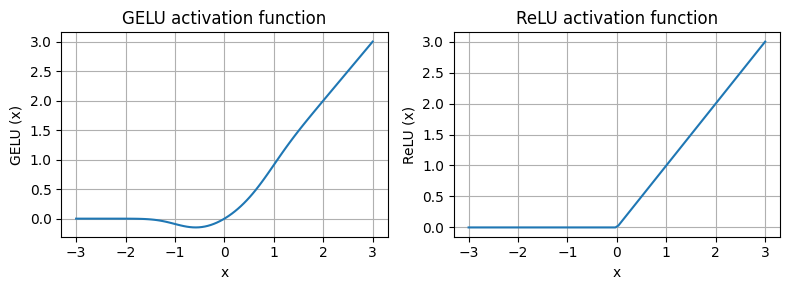

In [ ]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))

for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
  plt.subplot(1, 2, i)
  plt.plot(x, y)
  plt.title(f"{label} activation function")
  plt.xlabel("x")
  plt.ylabel(f"{label} (x)")
  plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
class FeedForward(nn.Module):

  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        # 출력층을 기존 embedding 층의 4배로 늘립
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
        GELU(),
        # 출력층을 다시 원본 embedding 층의 크기로 만듬
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
    )

  def forward(self, x):
    return self.layers(x)

In [ ]:
ftn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2,3, 768)
out = ftn(x)
print(out.shape)

torch.Size([2, 3, 768])


# 🔗 숏컷 연결 (Shortcut Connection / Skip Connection)

### 1. 핵심 개념
* **정의:** 특정 층(Layer)의 입력값($x$)을 출력값($F(x)$)에 직접 더해주는 구조
* **별칭:** 잔차 연결(Residual Connection), 스킵 연결(Skip Connection)
* **유래:** 2015년 ResNet(Residual Network) 모델에서 최초 제안
* **철학:** "기존 정보를 보존하면서, 추가로 학습할 '차이(Residual)'만 배우자"

---

### 2. 수학적 표현
$$y = F(x) + x$$
* **$x$:** 입력 데이터 (Identity Mapping, 보존할 정보)
* **$F(x)$:** 가중치 층을 통과한 결과 (Residual, 새로 학습할 정보)
* **$y$:** 최종 출력 (원본 + 변화량)

---

### 3. 도입 목적 및 효과
* **기울기 소실(Vanishing Gradient) 방지:** 역전파 시 숏컷 경로를 통해 기울기가 하위 층으로 손실 없이 전달
* **성능 저하(Degradation) 문제 해결:** 층이 깊어질수록 오차가 커지는 현상을 막아 수천 층까지 설계 가능
* **학습 안정화:** 입력 데이터의 특성이 유지되어 모델 최적화 난이도 하향

---

### 4. LLM (Transformer)에서의 구조적 적용


#### ① 숏컷 연결 1 (Attention 블록)
* **구조:** `입력 x + [LayerNorm -> Masked Multi-Head Attention -> Dropout]`
* **역할:** 문맥 정보를 추출하면서도 단어 고유의 정체성과 위치 정보 보존

#### ② 숏컷 연결 2 (Feed Forward 블록)
* **구조:** `입력 x + [LayerNorm -> Feed Forward -> Dropout]`
* **역할:** 특징 변환 및 차원 확장 과정에서 발생하는 데이터 왜곡 방지

---

### 5. 요약 및 시사점
* **딥러닝의 필수 요소:** 현대 모든 고성능 모델(GPT, Llama, Claude 등)의 표준 아키텍처
* **앙상블 효과:** 여러 경로가 조합되어 다양한 수준의 특징을 동시에 학습하는 효과 발생
* **단순함의 미학:** 파라미터 추가 없이 단순 덧셈만으로 성능 비약적 향상

In [ ]:
class ExampleDNN(nn.Module):

  def __init__(self, layer_sizes, use_shortcut) :
    super().__init__()
    self.use_shortcut = use_shortcut
    self.layers = nn.ModuleList(
        [
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ]
    )

  def forward(self, x):
    for layer in self.layers:
      layer_output = layer(x)
      print(x.shape)
      print(layer_output)
      if self.use_shortcut and x.shape == layer_output.shape:
        x = x + layer_output
      else:
        x = layer_output
    return x

def print_gradients(model, x):
  output = model(x)
  target = torch.tensor([0.])

  loss = nn.MSELoss()
  loss = loss(output, target)

  loss.backward()


  for name, param in model.named_parameters():
    if 'weight' in name:
      print(f"{name}의 평균 그레디언트는 {param.grad.abs().mean().item()}입니다.")


In [ ]:
torch.manual_seed(123)
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])
dnn_without_shortcut = ExampleDNN(layer_sizes, False)

print_gradients(dnn_without_shortcut, sample_input)

torch.Size([1, 3])
tensor([[ 0.1962, -0.1370,  0.0910]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.0207, 0.1366, 0.3943]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.0878, 0.2185, 0.0374]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[-0.0357, -0.0550,  0.1187]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.0610]], grad_fn=<MulBackward0>)
layers.0.0.weight의 평균 그레디언트는 0.000204713229322806입니다.
layers.1.0.weight의 평균 그레디언트는 0.00012317953223828226입니다.
layers.2.0.weight의 평균 그레디언트는 0.0007344746263697743입니다.
layers.3.0.weight의 평균 그레디언트는 0.0013871209230273962입니다.
layers.4.0.weight의 평균 그레디언트는 0.005026495084166527입니다.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [ ]:
layer_sizes = [3, 3, 3, 3, 3, 1]
torch.manual_seed(123)
sample_input = torch.tensor([[1., 0., -1.]])
dnn_with_shortcut = ExampleDNN(layer_sizes, True)

print_gradients(dnn_with_shortcut, sample_input)

torch.Size([1, 3])
tensor([[ 0.1962, -0.1370,  0.0910]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[-0.0961, -0.1029, -0.0010]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.0785, 1.2755, 0.0972]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[-0.1339,  0.0511,  0.4847]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.8845]], grad_fn=<MulBackward0>)
layers.0.0.weight의 평균 그레디언트는 0.29920274019241333입니다.
layers.1.0.weight의 평균 그레디언트는 0.2749510407447815입니다.
layers.2.0.weight의 평균 그레디언트는 0.454661101102829입니다.
layers.3.0.weight의 평균 그레디언트는 0.3629586696624756입니다.
layers.4.0.weight의 평균 그레디언트는 1.763088583946228입니다.


#### 어텐션 및 선형층 트랜스포머 블록에 연결

In [ ]:
!wget https://bit.ly/43BW1j3 -O previous_chapters.py

--2026-02-06 11:59:10--  https://bit.ly/43BW1j3
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch04/01_main-chapter-code/previous_chapters.py [following]
--2026-02-06 11:59:10--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch04/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4199 (4.1K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]   4.10K  --.-KB/s    in 0s      

2026-02-06 11:59:10 (33.6 MB/s) - ‘previous_chapter

In [ ]:
from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):

    # 멀티 헤드 어텐션 (단어 간 맥락(관계) 파악)
    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    # 피드 포워드 네트워크
    # 데이터를 늘렸다 줄였다 하면서 각 단어 마다 복잡한 특징을 추출

    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    return x


In [ ]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print(x.shape)
print(output.shape)


torch.Size([2, 4, 768])
torch.Size([2, 4, 768])


# 🤖 GPT 모델 입출력 및 아키텍처 요약

GPT 모델이 텍스트 입력을 받아 다음 토큰을 예측하기까지의 핵심 연산 흐름

---

### 1️⃣ 입력 처리 및 임베딩 (Input & Embedding)

모델에 들어온 텍스트는 숫자 형태의 고차원 벡터로 변환됨

* **텍스트 토큰화 (Tokenization)**: 문장을 단어 또는 서브워드 단위의 토큰 ID로 분리
* **토큰 임베딩 (Token Embedding)**: 토큰 ID를 고차원 공간의 벡터로 매핑
    * **Shape**: $(50257, 768)$ — *GPT-2 기준 어휘 사전 크기와 임베딩 차원*
* **위치 임베딩 (Positional Embedding)**: 각 토큰에 순서 정보를 부여
* **드롭아웃 (Dropout)**: 학습 시 과적합 방지를 위한 무작위 노드 비활성화

---

### 2️⃣ 트랜스포머 블록 (Transformer Block)

GPT-2 Small 기준, 아래의 구조가 **12번 반복**되어 심층적인 문맥 정보를 추출됨.



| 단계 | 구성 요소 | 역할 및 특징 |
| :--- | :--- | :--- |
| **Step 1** | **층 정규화 1 (Layer Norm)** | 학습의 안정성을 위해 입력값의 평균과 분산을 조정 |
| **Step 2** | **마스크드 멀티헤드 어텐션** | **Masking**을 통해 미래 토큰을 가리고, 과거 토큰들과의 연관성 계산 |
| **Step 3** | **드롭아웃 & 숏컷 연결** | Residual Connection을 통해 원본 정보를 유지하며 기울기 소실 방지 |
| **Step 4** | **층 정규화 2 (Layer Norm)** | 피드 포워드 연산 전 데이터 정규화 |
| **Step 5** | **피드 포워드 (FFN)** | 선형 층과 활성화 함수를 거쳐 토큰의 특징을 비선형적으로 확장 |
| **Step 6** | **드롭아웃 & 숏컷 연결** | 블록의 최종 출력값을 다음 층으로 전달 |

---

### 3️⃣ 최종 출력층 및 행렬 연산 (Output Layer)

압축된 특징 벡터를 다시 단어 확률 분포로 변환하는 단계

#### 🔢 연산 프로세스
1.  **최종 층 정규화 (Final Layer Norm)**: 12개의 블록을 거친 출력값을 최종 정렬
2.  **선형 출력층 (Linear Output Layer)**: 768차원 임베딩을 어휘 사전 크기로 확장

#### 📐 행렬 차원 (Matrix Multiplication)
마지막 선형층에서의 연산

$$(\text{context_length}, 768) \times (768, 50257) = (\text{context_length}, 50257)$$

---

### 🚀 결과 생성 (Generation)
최종 출력된 **Logits** 값에 `Softmax` 함수를 적용하면 다음 토큰이 될 확률 분포가 계산되며, 이 중 가장 적절한 토큰을 선택하여 문장을 이어감